# FV-WENO-1D & FD-WENO-1D

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update(
    {
        "savefig.dpi": 300,
        "figure.autolayout": True,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "lines.linewidth": 1.0,
        "lines.markersize": 5,
        "axes.linewidth": 1.0,
        "lines.markerfacecolor": "none",
        "lines.markeredgecolor": "auto",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 1.0,
    }
)

In [2]:
def order(xlist, ylist):
    return -np.log(ylist[1:] / ylist[:-1]) / np.log(xlist[1:] / xlist[:-1])


def err_table(nums, err_l1, err_l2, err_inf):
    ord_l1 = order(nums, err_l1)
    ord_l2 = order(nums, err_l2)
    ord_linf = order(nums, err_inf)

    data = {
        "m": nums,
        "L1 error": err_l1,
        "L1 order": np.r_[np.nan, ord_l1],
        "L2 error": err_l2,
        "L2 order": np.r_[np.nan, ord_l2],
        "Linf error": err_inf,
        "Linf order": np.r_[np.nan, ord_linf],
    }

    return pd.DataFrame(data)


In [3]:
def burgers_f(u):
    return u**2 / 2


def burgers_df(u):
    return u


def burgers_fhat_godunov(ul, ur):
    flux = np.where(
        ul <= ur,
        np.where(ul * ur > 0, np.minimum(burgers_f(ul), burgers_f(ur)), 0),
        np.maximum(burgers_f(ul), burgers_f(ur)),
    )
    return flux


def get_LF_flux(f, get_alpha):
    def fhat_lf(ul, ur):
        return (f(ul) + f(ur)) / 2 - get_alpha(ul, ur) / 2 * (ur - ul)

    return fhat_lf


def burgers_get_alpha(ul, ur):
    return np.maximum(np.abs(burgers_df(ul)), np.abs(burgers_df(ur)))


def burgers_f_split_l(u, c):
    return u**2 / 4 + c / 2 * u


def burgers_f_split_r(u, c):
    return u**2 / 4 - c / 2 * u

In [4]:
def burgers_sin_solver_kernel(x, t):
    u = x / (np.pi / 2 + t)  # u0

    # Newton iteration
    for _ in range(100000):
        du = (u - np.sin(x - u * t)) / (1 + np.cos(x - u * t) * t)
        u = u - du

        if np.max(np.abs(du)) < 1e-10:
            break

    return u


def burgers_sin_solver(x, t, a, b, w, phi):
    x_tilde = w * x + phi - a * w * t
    x_tilde = np.mod(x_tilde + np.pi, 2 * np.pi) - np.pi  # in [-pi, pi]
    t_tilde = b * w * t

    return a + b * burgers_sin_solver_kernel(x_tilde, t_tilde)

In [5]:
def gauss5(f, x, dx):
    # Guass-Legendre quadrature weights and nodes

    nodes, weights = np.polynomial.legendre.leggauss(5)

    flag = np.isscalar(x)
    x = np.atleast_1d(x)
    x_nodes = x[:, None] + dx / 2 * nodes

    result = dx / 2 * np.sum(f(x_nodes) * weights, axis=1)

    return result[0] if flag else result


In [6]:
def burgers_sin_solver_mean(x, t, dx, a, b, w, phi):
    return gauss5(lambda s: burgers_sin_solver(s, t, a, b, w, phi), x, dx) / dx


def burgers_init_mean(x, dx, a, b):
    return gauss5(lambda s: a + b * np.sin(s), x, dx) / dx


def burgers_init(x, a, b):
    return a + b * np.sin(x)

In [7]:
def compute_weno5_flux(u, left=True, right=True):
    EPSILON = 1e-6
    LINEAR_WEIGHTS = np.array([[3 / 10, 3 / 5, 1 / 10], [1 / 10, 3 / 5, 3 / 10]])

    ul2 = np.roll(u, 2)
    ul1 = np.roll(u, 1)
    ur1 = np.roll(u, -1)
    ur2 = np.roll(u, -2)

    def compute_weno5_beta(u):

        beta1 = (
            13 / 12 * (ul2 - 2 * ul1 + u) ** 2 + 1 / 4 * (ul2 - 4 * ul1 + 3 * u) ** 2
        )
        beta2 = 13 / 12 * (ul1 - 2 * u + ur1) ** 2 + 1 / 4 * (ul1 - ur1) ** 2
        beta3 = (
            13 / 12 * (u - 2 * ur1 + ur2) ** 2 + 1 / 4 * (3 * u - 4 * ur1 + ur2) ** 2
        )

        return np.stack([beta1, beta2, beta3], axis=1)

    beta = compute_weno5_beta(u)

    ul_hat = np.zeros_like(u)
    ur_hat = np.zeros_like(u)

    if left:
        w_left = LINEAR_WEIGHTS[0] / (beta + EPSILON) ** 2
        w_left /= np.sum(w_left, axis=1, keepdims=True)

        ul_pre = np.stack(
            [
                -(1 / 6) * ul2 + (5 / 6) * ul1 + (1 / 3) * u,
                (1 / 3) * ul1 + (5 / 6) * u - (1 / 6) * ur1,
                (11 / 6) * u - (7 / 6) * ur1 + (1 / 3) * ur2,
            ],
            axis=1,
        )
        ul_hat = np.sum(w_left * ul_pre, axis=1)

    if right:
        w_right = LINEAR_WEIGHTS[1] / (beta + EPSILON) ** 2
        w_right /= np.sum(w_right, axis=1, keepdims=True)

        ur_pre = np.stack(
            [
                (1 / 3) * np.roll(u, 2) - (7 / 6) * np.roll(u, 1) + (11 / 6) * u,
                -(1 / 6) * np.roll(u, 1) + (5 / 6) * u + (1 / 3) * np.roll(u, -1),
                (1 / 3) * u + (5 / 6) * np.roll(u, -1) - (1 / 6) * np.roll(u, -2),
            ],
            axis=1,
        )
        ur_hat = np.sum(w_right * ur_pre, axis=1)

    return ul_hat, ur_hat

In [8]:
def SSP_RK3(u, dt, op_L, **kwargs):
    u1 = u + dt * op_L(u, **kwargs)
    u2 = 3 / 4 * u + 1 / 4 * (u1 + dt * op_L(u1, **kwargs))
    unew = 1 / 3 * u + 2 / 3 * (u2 + dt * op_L(u2, **kwargs))
    return unew

In [9]:
def FVWENO5(uh0, dx, tend, fhat, df):

    def op_L(u):
        ul_hat, ur_hat = compute_weno5_flux(u)

        fhat_r = fhat(ur_hat, np.roll(ul_hat, -1))
        fhat_l = fhat(np.roll(ur_hat, 1), ul_hat)

        return -1 / dx * (fhat_r - fhat_l)

    uh = uh0.copy()
    tnow = 0
    while tnow < tend:
        c = np.max(np.abs(df(uh)))
        dtnow = min(1 / (2 * c) * dx ** (5 / 3), tend - tnow)
        uh = SSP_RK3(uh, dtnow, op_L)
        tnow += dtnow

    return uh

In [10]:
def FVWENO5_test():
    tend = 0.5
    nums = np.array([10, 20, 40, 80, 160, 320, 640])
    error_inf = np.zeros_like(nums, dtype=np.float64)
    error_l1 = np.zeros_like(nums, dtype=np.float64)
    error_l2 = np.zeros_like(nums, dtype=np.float64)

    for cnt, num in enumerate(nums):
        x, dx = np.linspace(-np.pi, np.pi, num, endpoint=False, retstep=True)
        x += dx / 2

        u0 = burgers_init_mean(x, dx, a=0.5, b=1)
        uh = FVWENO5(
            u0, dx, tend, get_LF_flux(burgers_f, burgers_get_alpha), burgers_df
        )
        u_exact = burgers_sin_solver_mean(x, tend, dx, a=0.5, b=1, w=1, phi=0)

        error_inf[cnt] = np.linalg.norm(u_exact - uh, ord=np.inf)
        error_l1[cnt] = np.linalg.norm(u_exact - uh, ord=1) * dx
        error_l2[cnt] = np.linalg.norm(u_exact - uh, ord=2) * np.sqrt(dx)

    df = err_table(nums, error_l1, error_l2, error_inf)
    print(df.to_string(index=False, float_format="%.2e"))

    tend = 1.5

    num_ref = 320
    x_ref, dx_ref = np.linspace(-np.pi, np.pi, num_ref, endpoint=False, retstep=True)
    x_ref += dx_ref / 2

    u_exact_ref = burgers_sin_solver_mean(x_ref, tend, dx_ref, a=0.5, b=1, w=1, phi=0)

    for num in [40, 160]:
        x, dx = np.linspace(-np.pi, np.pi, num, endpoint=False, retstep=True)
        x += dx / 2

        u0 = burgers_init_mean(x, dx, a=0.5, b=1)
        uh = FVWENO5(
            u0, dx, tend, get_LF_flux(burgers_f, burgers_get_alpha), burgers_df
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(x_ref, u_exact_ref, label=r"$u_{\textnormal{exact}}$")
        ax.plot(
            x,
            uh,
            linestyle="None",
            marker="o",
            markersize=5,
            markerfacecolor="none",
            label="$u_h$",
        )
        ax.legend()
        ax.grid()

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 10  2.35e-02       NaN  1.41e-02       NaN    1.25e-02         NaN
 20  3.20e-03  2.88e+00  2.32e-03  2.61e+00    2.70e-03    2.21e+00
 40  2.28e-04  3.81e+00  2.01e-04  3.53e+00    3.48e-04    2.96e+00
 80  1.18e-05  4.27e+00  1.00e-05  4.32e+00    1.64e-05    4.40e+00
160  5.09e-07  4.54e+00  4.74e-07  4.40e+00    1.27e-06    3.69e+00
320  1.57e-08  5.02e+00  1.51e-08  4.97e+00    4.64e-08    4.78e+00
640  3.73e-10  5.39e+00  3.46e-10  5.45e+00    6.21e-10    6.22e+00


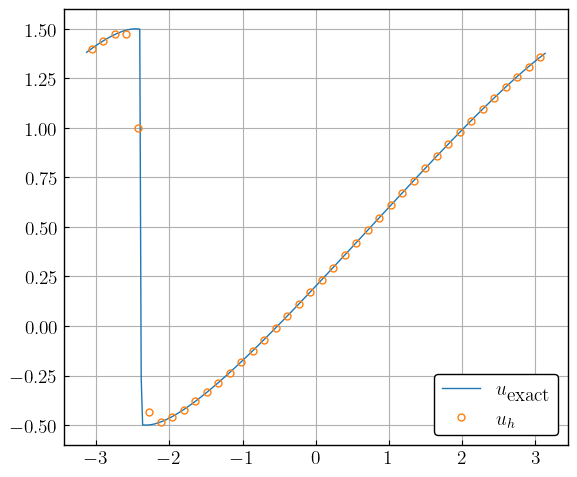

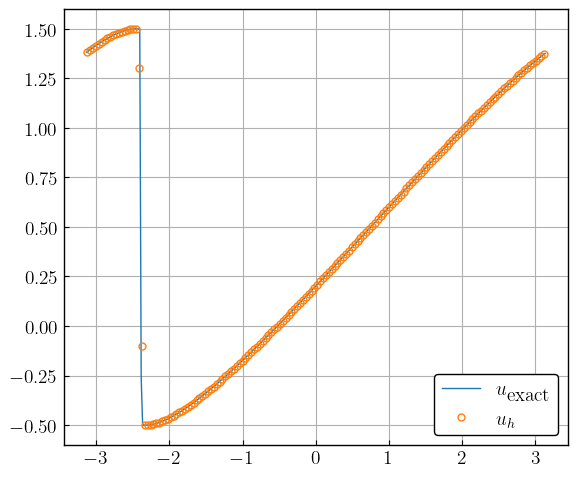

In [11]:
FVWENO5_test()

In [12]:
def FDWENO5(uh0, dx, tend, fl, fr, df):

    def op_L(u):
        c = np.max(np.abs(df(u)))

        hl_list = fl(u, c)
        hr_list = fr(u, c)

        _, hlr_hat = compute_weno5_flux(hl_list, left=False)
        hrl_hat, _ = compute_weno5_flux(hr_list, right=False)

        v = (hlr_hat + np.roll(hrl_hat, -1)) - (np.roll(hlr_hat, 1) + hrl_hat)
        return -1 / dx * v

    uh = uh0.copy()
    tnow = 0
    while tnow < tend:
        c = np.max(np.abs(df(uh)))
        dtnow = min(1 / (2 * c) * dx ** (5 / 3), tend - tnow)
        uh = SSP_RK3(uh, dtnow, op_L)
        tnow += dtnow

    return uh

In [13]:
def FDWENO5_test():
    tend = 0.5
    nums = np.array([10, 20, 40, 80, 160, 320, 640])
    error_inf = np.zeros_like(nums, dtype=np.float64)
    error_l1 = np.zeros_like(nums, dtype=np.float64)
    error_l2 = np.zeros_like(nums, dtype=np.float64)

    for cnt, num in enumerate(nums):
        x, dx = np.linspace(-np.pi, np.pi, num, endpoint=False, retstep=True)
        x += dx / 2

        u0 = burgers_init(x, a=0.5, b=1)
        uh = FDWENO5(u0, dx, tend, burgers_f_split_l, burgers_f_split_r, burgers_df)

        u_exact = burgers_sin_solver(x, tend, a=0.5, b=1, w=1, phi=0)

        error_inf[cnt] = np.linalg.norm(u_exact - uh, ord=np.inf)
        error_l1[cnt] = np.linalg.norm(u_exact - uh, ord=1) * dx
        error_l2[cnt] = np.linalg.norm(u_exact - uh, ord=2) * np.sqrt(dx)

    df = err_table(nums, error_l1, error_l2, error_inf)
    print(df.to_string(index=False, float_format="%.2e"))

    tend = 1.5

    num_ref = 320
    x_ref, dx_ref = np.linspace(-np.pi, np.pi, num_ref, endpoint=False, retstep=True)
    x_ref += dx_ref / 2

    u_exact_ref = burgers_sin_solver(x_ref, tend, a=0.5, b=1, w=1, phi=0)

    for num in [40, 160]:
        x, dx = np.linspace(-np.pi, np.pi, num, endpoint=False, retstep=True)
        x += dx / 2

        u0 = burgers_init(x, a=0.5, b=1)
        uh = FDWENO5(u0, dx, tend, burgers_f_split_l, burgers_f_split_r, burgers_df)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(x_ref, u_exact_ref, label=r"$u_{\textnormal{exact}}$")
        ax.plot(
            x,
            uh,
            linestyle="None",
            marker="o",
            markersize=5,
            markerfacecolor="none",
            label="$u_h$",
        )
        ax.legend()
        ax.grid()

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 10  9.74e-02       NaN  5.02e-02       NaN    4.23e-02         NaN
 20  1.29e-02  2.91e+00  1.04e-02  2.27e+00    1.49e-02    1.51e+00
 40  7.54e-04  4.10e+00  6.79e-04  3.94e+00    1.14e-03    3.70e+00
 80  2.83e-05  4.74e+00  2.59e-05  4.71e+00    4.38e-05    4.71e+00
160  1.03e-06  4.78e+00  8.96e-07  4.85e+00    1.40e-06    4.96e+00
320  3.02e-08  5.09e+00  2.82e-08  4.99e+00    7.74e-08    4.18e+00
640  7.07e-10  5.42e+00  6.68e-10  5.40e+00    1.19e-09    6.03e+00


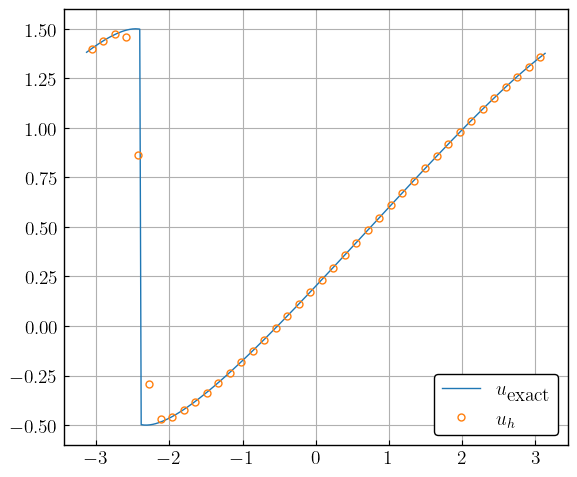

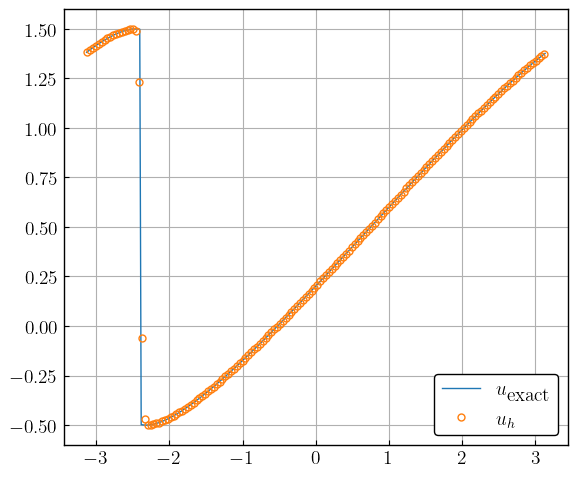

In [14]:
FDWENO5_test()